In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install vaderSentiment textblob textstat --quiet

print("Libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.7 MB/s eta 0:00:00
Libraries installed successfully


In [3]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import textstat

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
df = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/df_cleaned.csv")

print(f"Dataset loaded: {len(df)} articles")
print(df["label"].value_counts())

Dataset loaded: 38590 articles
label
REAL    21191
FAKE    17399
Name: count, dtype: int64


In [5]:
print("Extracting sentiment scores...")

analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

print("Done")
print(f"\nSentiment score statistics:")
print(df.groupby("label")["sentiment"].describe().round(3))

Extracting sentiment scores...
Done

Sentiment score statistics:
         count   mean    std  min    25%    50%    75%  max
label                                                      
FAKE   17399.0 -0.075  0.861 -1.0 -0.964 -0.340  0.920  1.0
REAL   21191.0  0.072  0.819 -1.0 -0.886  0.273  0.923  1.0


In [6]:
print("Extracting subjectivity scores...")

df["subjectivity"] = df["text"].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)

print("Done")
print(f"\nSubjectivity score statistics:")
print(df.groupby("label")["subjectivity"].describe().round(3))

Extracting subjectivity scores...
Done

Subjectivity score statistics:
         count   mean    std  min    25%    50%    75%  max
label                                                      
FAKE   17399.0  0.454  0.114  0.0  0.395  0.456  0.516  1.0
REAL   21191.0  0.362  0.116  0.0  0.303  0.368  0.426  1.0


In [7]:
print("Extracting readability scores...")

df["readability"] = df["text"].apply(
    lambda x: textstat.flesch_reading_ease(str(x))
)

print("Done")
print(f"\nReadability score statistics:")
print(df.groupby("label")["readability"].describe().round(3))

Extracting readability scores...
Done

Readability score statistics:
         count    mean     std      min     25%     50%     75%      max
label                                                                   
FAKE   17399.0  52.355  12.725 -416.610  45.598  52.928  59.695  121.220
REAL   21191.0  42.312   9.657  -25.587  36.837  42.802  48.416   82.589


In [8]:
print("Extracting punctuation features...")

# These must be extracted from RAW text before cleaning
df["exclamation_count"] = df["text"].apply(
    lambda x: str(x).count("!")
)

df["question_count"] = df["text"].apply(
    lambda x: str(x).count("?")
)

df["caps_ratio"] = df["text"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

print("Done")
print(f"\nExclamation mark statistics:")
print(df.groupby("label")["exclamation_count"].describe().round(3))
print(f"\nCaps ratio statistics:")
print(df.groupby("label")["caps_ratio"].describe().round(3))

Extracting punctuation features...
Done

Exclamation mark statistics:
         count   mean    std  min  25%  50%  75%    max
label                                                  
FAKE   17399.0  0.744  2.008  0.0  0.0  0.0  1.0  133.0
REAL   21191.0  0.062  0.419  0.0  0.0  0.0  0.0   12.0

Caps ratio statistics:
         count   mean    std    min    25%    50%    75%    max
label                                                          
FAKE   17399.0  0.045  0.045  0.008  0.029  0.036  0.047  0.882
REAL   21191.0  0.042  0.015  0.010  0.032  0.038  0.048  0.221


/tmp/ipykernel_1444/241954379.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="sentiment", data=df,
/tmp/ipykernel_1444/241954379.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="subjectivity", data=df,
/tmp/ipykernel_1444/241954379.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="readability", data=df,
/tmp/ipykernel_1444/241954379.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

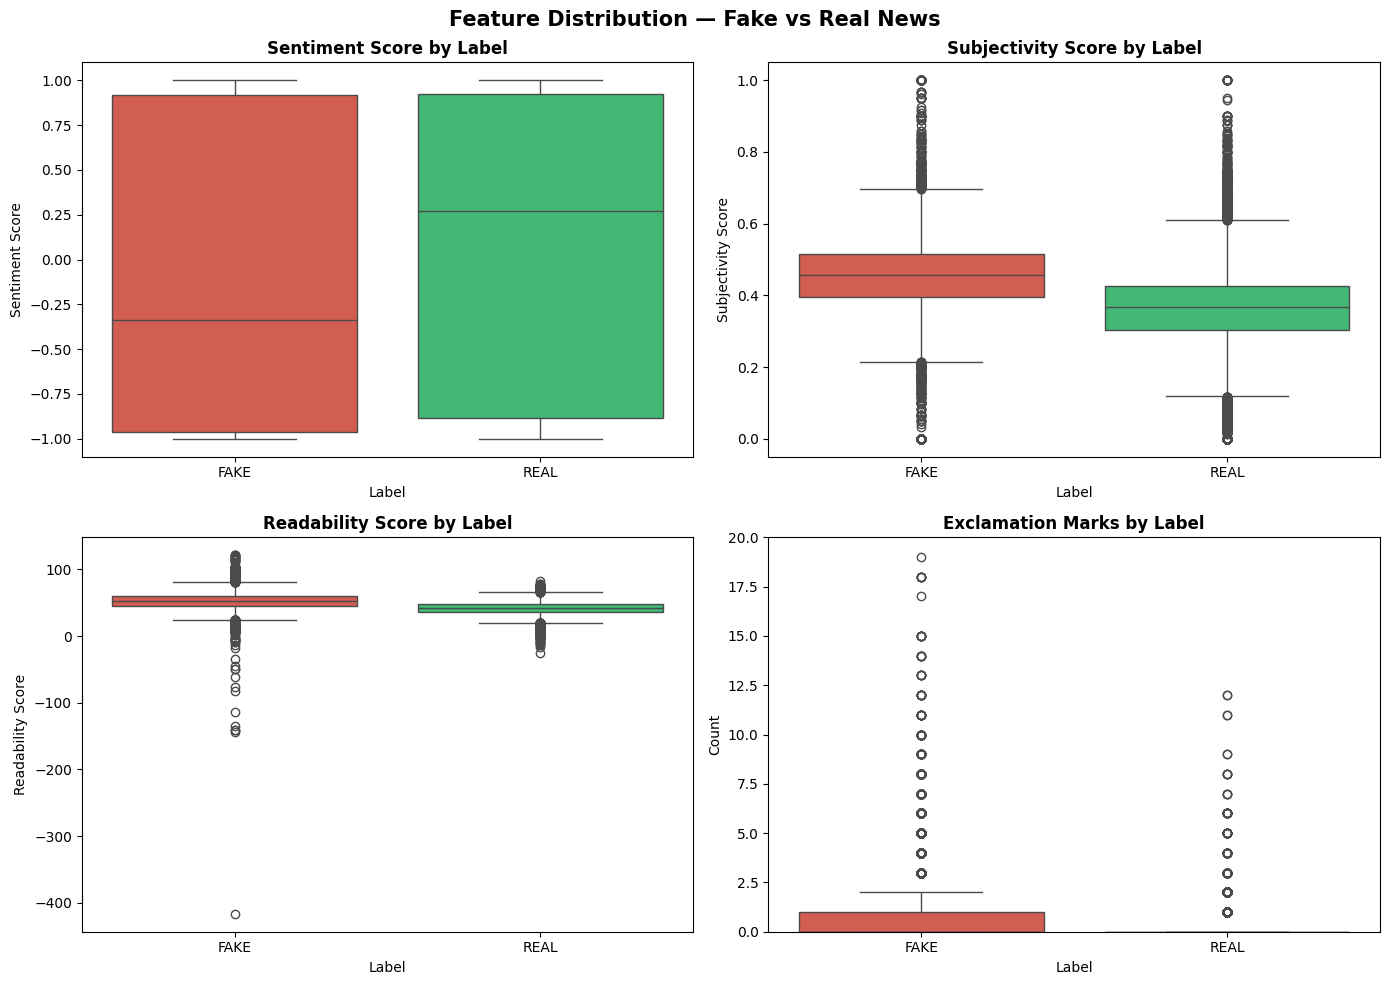

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sentiment
sns.boxplot(x="label", y="sentiment", data=df,
            palette=["#E74C3C", "#2ECC71"], ax=axes[0,0])
axes[0,0].set_title("Sentiment Score by Label", fontweight="bold")
axes[0,0].set_xlabel("Label")
axes[0,0].set_ylabel("Sentiment Score")

# Subjectivity
sns.boxplot(x="label", y="subjectivity", data=df,
            palette=["#E74C3C", "#2ECC71"], ax=axes[0,1])
axes[0,1].set_title("Subjectivity Score by Label", fontweight="bold")
axes[0,1].set_xlabel("Label")
axes[0,1].set_ylabel("Subjectivity Score")

# Readability
sns.boxplot(x="label", y="readability", data=df,
            palette=["#E74C3C", "#2ECC71"], ax=axes[1,0])
axes[1,0].set_title("Readability Score by Label", fontweight="bold")
axes[1,0].set_xlabel("Label")
axes[1,0].set_ylabel("Readability Score")

# Exclamation count
sns.boxplot(x="label", y="exclamation_count", data=df,
            palette=["#E74C3C", "#2ECC71"], ax=axes[1,1])
axes[1,1].set_title("Exclamation Marks by Label", fontweight="bold")
axes[1,1].set_xlabel("Label")
axes[1,1].set_ylabel("Count")
axes[1,1].set_ylim(0, 20)

plt.suptitle("Feature Distribution — Fake vs Real News",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/feature_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
features = ["sentiment", "subjectivity", "readability",
            "exclamation_count", "question_count", "caps_ratio"]

print("=" * 60)
print("FEATURE SUMMARY — FAKE vs REAL")
print("=" * 60)
for feature in features:
    fake_mean = df[df["label"] == "FAKE"][feature].mean()
    real_mean = df[df["label"] == "REAL"][feature].mean()
    diff = fake_mean - real_mean
    print(f"\n{feature}:")
    print(f"  Fake mean: {fake_mean:.4f}")
    print(f"  Real mean: {real_mean:.4f}")
    print(f"  Difference: {diff:+.4f}")
print("=" * 60)

FEATURE SUMMARY — FAKE vs REAL

sentiment:
  Fake mean: -0.0749
  Real mean: 0.0716
  Difference: -0.1464

subjectivity:
  Fake mean: 0.4540
  Real mean: 0.3619
  Difference: +0.0921

readability:
  Fake mean: 52.3553
  Real mean: 42.3117
  Difference: +10.0436

exclamation_count:
  Fake mean: 0.7441
  Real mean: 0.0621
  Difference: +0.6820

question_count:
  Fake mean: 1.2347
  Real mean: 0.1000
  Difference: +1.1347

caps_ratio:
  Fake mean: 0.0448
  Real mean: 0.0418
  Difference: +0.0030


In [11]:
df.to_csv("/content/drive/MyDrive/FactLens_Group9/data/df_with_features.csv",
          index=False)

print("Saved successfully as df_with_features.csv")
print(f"\nColumns saved:")
print(df.columns.tolist())

Saved successfully as df_with_features.csv

Columns saved:
['title', 'text', 'subject', 'date', 'label', 'text_length', 'word_count', 'cleaned_text', 'word_count_before', 'word_count_after', 'sentiment', 'subjectivity', 'readability', 'exclamation_count', 'question_count', 'caps_ratio']
